# Análise do Mercado de Trabalho em Tecnologia da Informação no Brasil (2015–2024)

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python
**Projeto G2 — Tema 25**

---

## 1. Introdução

Este notebook documenta todo o fluxo analítico do projeto: leitura da base, limpeza, engenharia de atributos,
indicadores (KPIs), visualizações, interpretação e conclusão. Os resultados alimentam o dashboard em
Streamlit (`app.py`) e a página de apresentação (`index.html`).

**Problema:** quais cargos e tecnologias concentram a demanda por profissionais de TI no Brasil, como os salários
evoluíram e onde estão as oportunidades?

**Perguntas orientadoras**
1. Quais cargos possuem maior demanda?
2. Quais tecnologias aparecem com maior frequência?
3. Houve crescimento salarial ao longo do tempo?
4. Existem diferenças regionais relevantes?
5. Quais áreas de TI possuem maior crescimento?
6. Qual nível de experiência é mais exigido?
7. Quais regiões concentram mais oportunidades?

## 2. Contextualização do mercado de TI

A transformação digital acelerou a demanda por profissionais de **desenvolvimento de software, ciência de dados,
inteligência artificial, segurança da informação e computação em nuvem**. A pandemia de 2020–2021 adicionou outro
fator: a adoção em massa do trabalho remoto, que mudou a forma de contratar e ampliou a concorrência entre regiões.

Ao mesmo tempo, o Brasil enfrentou anos de inflação elevada (10,67% em 2015 e 10,06% em 2021), o que torna
essencial analisar o salário **real** — e não apenas o nominal — para entender se a remuneração de fato cresceu.

## 3. Explicação da base de dados

Arquivo: `dados/simulacao_mercado_ti_brasil.csv` (dataset **simulado** fornecido pela disciplina).

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período de referência da vaga |
| regiao, uf, cidade | Localização |
| cargo | Nome da vaga |
| senioridade | Júnior, Pleno, Sênior |
| tecnologia | Python, Java, SQL, JavaScript, AWS, Power BI |
| modalidade | Presencial, Híbrido, Remoto |
| salario_medio | Salário médio (R$) |
| quantidade_vagas | Número de vagas |
| empresa_setor | Segmento da empresa |
| nivel_demanda | Baixo, Médio, Alto, Crítico |

**Fonte complementar:** IPCA mensal da API pública do Banco Central (SGS, série 433), usado para calcular o salário real.

## 4. Leitura dos dados

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RAIZ = Path("..")
IMG = RAIZ / "imagens"
IMG.mkdir(exist_ok=True)

# Identidade visual dos gráficos (paleta categórica validada para daltonismo)
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 13})

def salvar(fig, nome):
    fig.savefig(IMG / nome, facecolor="white")

df_bruto = pd.read_csv(RAIZ / "dados" / "simulacao_mercado_ti_brasil.csv", encoding="utf-8-sig")
print(f"Linhas: {df_bruto.shape[0]:,} | Colunas: {df_bruto.shape[1]}")
df_bruto.head()

Linhas: 4,440 | Colunas: 14


,ano,mes,data,regiao,uf,cidade,cargo,senioridade,tecnologia,modalidade,salario_medio,quantidade_vagas,empresa_setor,nivel_demanda
0,2015,1,2015-01-01,Norte,AM,Manaus,Cientista de Dados,Sênior,Java,Presencial,"7,919.27",40,Fintech,Baixo
1,2015,1,2015-01-01,Norte,PA,Belém,Cientista de Dados,Pleno,AWS,Presencial,"9,477.26",37,Varejo,Alto
2,2015,1,2015-01-01,Norte,PA,Santarém,Cientista de Dados,Sênior,Java,Híbrido,"17,314.96",45,Governo,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Analista de Dados,Sênior,Java,Remoto,"9,215.33",43,Saúde,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Dev Backend,Pleno,SQL,Remoto,"8,810.91",44,Saúde,Alto


In [2]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               4440 non-null   int64  
 1   mes               4440 non-null   int64  
 2   data              4440 non-null   str    
 3   regiao            4440 non-null   str    
 4   uf                4440 non-null   str    
 5   cidade            4440 non-null   str    
 6   cargo             4440 non-null   str    
 7   senioridade       4440 non-null   str    
 8   tecnologia        4440 non-null   str    
 9   modalidade        4440 non-null   str    
 10  salario_medio     4440 non-null   float64
 11  quantidade_vagas  4440 non-null   int64  
 12  empresa_setor     4440 non-null   str    
 13  nivel_demanda     4440 non-null   str    
dtypes: float64(1), int64(3), str(10)
memory usage: 813.3 KB


In [3]:
df_bruto.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,"4,440.00",NaN,NaN,NaN,"2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
mes,"4,440.00",NaN,NaN,NaN,6.50,3.45,1.00,3.75,6.50,9.25,12.00
data,4440,120,2015-01-01,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
regiao,4440,5,Sudeste,1560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uf,4440,20,RJ,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cidade,4440,37,Manaus,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cargo,4440,5,Cientista de Dados,930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senioridade,4440,3,Júnior,1515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tecnologia,4440,6,Java,770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modalidade,4440,3,Remoto,1517,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Limpeza e preparação

Etapas aplicadas:
1. Padronização de textos (remoção de espaços, UF em maiúsculas);
2. Conversão de tipos (numéricos e data);
3. Verificação de valores nulos e duplicados;
4. Regras de consistência (salário > 0, vagas ≥ 0, mês entre 1 e 12);
5. Identificação de outliers de salário pelo critério IQR;
6. Conversão de colunas ordinais em categorias ordenadas.

In [4]:
df = df_bruto.copy()
df.columns = df.columns.str.strip().str.lower()

texto = ["regiao", "uf", "cidade", "cargo", "senioridade", "tecnologia", "modalidade", "empresa_setor", "nivel_demanda"]
for c in texto:
    df[c] = df[c].astype("string").str.strip()
df["uf"] = df["uf"].str.upper()

for c in ["ano", "mes", "salario_medio", "quantidade_vagas"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["data"] = pd.to_datetime(df["data"], errors="coerce")

print("Valores nulos por coluna:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "  nenhum valor nulo")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Valores nulos por coluna:
  nenhum valor nulo
Linhas duplicadas: 0


In [5]:
antes = len(df)
df = df.drop_duplicates().dropna(subset=["ano", "mes", "uf", "cargo", "salario_medio", "quantidade_vagas"])
invalidas = (df["salario_medio"] <= 0) | (df["quantidade_vagas"] < 0) | (~df["mes"].between(1, 12))
df = df[~invalidas]
print(f"Linhas inválidas removidas: {invalidas.sum()} | Linhas restantes: {len(df)} de {antes}")

# Outliers pelo IQR (apenas sinalizados)
q1, q3 = df["salario_medio"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df["outlier_salario"] = ~df["salario_medio"].between(lim_inf, lim_sup)
print(f"Limites IQR: R$ {lim_inf:,.2f} a R$ {lim_sup:,.2f} → outliers: {df['outlier_salario'].sum()}")

# Categorias ordenadas
df["senioridade"] = pd.Categorical(df["senioridade"], ["Júnior", "Pleno", "Sênior"], ordered=True)
df["nivel_demanda"] = pd.Categorical(df["nivel_demanda"], ["Baixo", "Médio", "Alto", "Crítico"], ordered=True)
df["modalidade"] = pd.Categorical(df["modalidade"], ["Presencial", "Híbrido", "Remoto"], ordered=True)
df[["ano", "mes", "quantidade_vagas"]] = df[["ano", "mes", "quantidade_vagas"]].astype(int)

# Verificação de categorias
for c in ["regiao", "cargo", "senioridade", "tecnologia", "modalidade", "empresa_setor", "nivel_demanda"]:
    print(f"{c:15s}: {sorted(df[c].astype(str).unique())}")

Linhas inválidas removidas: 0 | Linhas restantes: 4440 de 4440
Limites IQR: R$ -4,259.66 a R$ 25,624.87 → outliers: 0
regiao         : ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
cargo          : ['Analista de Dados', 'Cientista de Dados', 'Dev Backend', 'Dev Frontend', 'DevOps']
senioridade    : ['Júnior', 'Pleno', 'Sênior']
tecnologia     : ['AWS', 'Java', 'JavaScript', 'Power BI', 'Python', 'SQL']
modalidade     : ['Híbrido', 'Presencial', 'Remoto']
empresa_setor  : ['Educação', 'Fintech', 'Governo', 'Saúde', 'Varejo']
nivel_demanda  : ['Alto', 'Baixo', 'Crítico', 'Médio']


**Diagnóstico:** a base chegou íntegra — sem nulos, duplicados, valores inválidos ou outliers pelo IQR
(salários entre R$ 3 mil e R$ 18 mil). As etapas de limpeza continuam no código porque o dashboard aceita **upload
de novos arquivos**, que podem não ser tão limpos.

## 6. Engenharia de atributos

| Atributo | Regra | Uso |
|---|---|---|
| `trimestre`, `ano_trimestre` | a partir do mês | análise temporal |
| `periodo` | Pré-pandemia, Pandemia, Pós-pandemia | comparação de fases |
| `area` | agrupamento de cargos | crescimento por área de TI |
| `faixa_salarial` | faixas de R$ 4 mil | distribuição salarial |
| `massa_salarial` | salário × vagas | peso econômico |
| `eh_remoto`, `peso_demanda` | variáveis numéricas | correlação |
| `ipca_pct`, `salario_real` | API do Banco Central | salário a preços de 2024 |

In [6]:
df["trimestre"] = (df["mes"] - 1) // 3 + 1
df["ano_trimestre"] = df["ano"].astype(str) + "-T" + df["trimestre"].astype(str)
df["periodo"] = pd.cut(df["ano"], bins=[2014, 2019, 2021, 2024],
                       labels=["Pré-pandemia", "Pandemia", "Pós-pandemia"])
df["area"] = df["cargo"].map({"Analista de Dados": "Dados", "Cientista de Dados": "Dados",
                              "Dev Backend": "Desenvolvimento", "Dev Frontend": "Desenvolvimento",
                              "DevOps": "Infraestrutura/Nuvem"})
df["faixa_salarial"] = pd.cut(df["salario_medio"], bins=[0, 6000, 10000, 14000, np.inf],
                              labels=["Até R$ 6 mil", "R$ 6–10 mil", "R$ 10–14 mil", "Acima de R$ 14 mil"])
df["massa_salarial"] = df["salario_medio"] * df["quantidade_vagas"]
df["eh_remoto"] = (df["modalidade"] == "Remoto").astype(int)
df["peso_demanda"] = df["nivel_demanda"].cat.codes + 1
df[["data", "cargo", "area", "periodo", "faixa_salarial", "massa_salarial", "eh_remoto", "peso_demanda"]].head()

,data,cargo,area,periodo,faixa_salarial,massa_salarial,eh_remoto,peso_demanda
0,2015-01-01,Cientista de Dados,Dados,Pré-pandemia,R$ 6–10 mil,"316,770.80",0,1
1,2015-01-01,Cientista de Dados,Dados,Pré-pandemia,R$ 6–10 mil,"350,658.62",0,3
2,2015-01-01,Cientista de Dados,Dados,Pré-pandemia,Acima de R$ 14 mil,"779,173.20",0,4
3,2015-01-01,Analista de Dados,Dados,Pré-pandemia,R$ 6–10 mil,"396,259.19",1,2
4,2015-01-01,Dev Backend,Desenvolvimento,Pré-pandemia,R$ 6–10 mil,"387,680.04",1,3


### 6.1 Integração com API — IPCA (Banco Central)

In [7]:
URL = ("https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados"
       "?formato=json&dataInicial=01/01/2015&dataFinal=31/12/2024")
try:
    resp = requests.get(URL, timeout=10)
    resp.raise_for_status()
    mensal = pd.DataFrame(resp.json())
    mensal["ano"] = pd.to_datetime(mensal["data"], format="%d/%m/%Y").dt.year
    mensal["valor"] = mensal["valor"].astype(float)
    ipca = (mensal.groupby("ano")["valor"].apply(lambda s: (np.prod(1 + s / 100) - 1) * 100)
            .round(2).reset_index(name="ipca_pct"))
    fonte = "API do Banco Central"
except Exception as erro:
    ipca = pd.read_csv(RAIZ / "dados" / "ipca_anual.csv")
    fonte = f"arquivo local de contingência ({type(erro).__name__})"
print("IPCA obtido de:", fonte)

ipca["indice"] = (1 + ipca["ipca_pct"] / 100).cumprod()
ipca["fator_2024"] = ipca.loc[ipca["ano"] == 2024, "indice"].iloc[0] / ipca["indice"]
df = df.merge(ipca[["ano", "ipca_pct", "fator_2024"]], on="ano", how="left")
df["salario_real"] = df["salario_medio"] * df["fator_2024"]
ipca

IPCA obtido de: arquivo local de contingência (ProxyError)


,ano,ipca_pct,indice,fator_2024
0,2015,10.67,1.11,1.58
1,2016,6.29,1.18,1.49
2,2017,2.95,1.21,1.44
3,2018,3.75,1.26,1.39
4,2019,4.31,1.31,1.33
5,2020,4.52,1.37,1.28
6,2021,10.06,1.51,1.16
7,2022,5.79,1.59,1.10
8,2023,4.62,1.67,1.05
9,2024,4.83,1.75,1.00


## 7. KPIs

Os seis indicadores pedidos no enunciado. O salário médio nacional é **ponderado pela quantidade de vagas**.

In [8]:
total_vagas = df["quantidade_vagas"].sum()
def lider(col):
    s = df.groupby(col, observed=True)["quantidade_vagas"].sum().sort_values(ascending=False)
    return s.index[0], s.iloc[0] / total_vagas * 100

kpis = pd.DataFrame([
    ["Total de vagas", f"{total_vagas:,}".replace(",", "."), "Mercado geral"],
    ["Cargo mais demandado", "%s (%.1f%%)" % lider("cargo"), "Ranking profissional"],
    ["Tecnologia mais requisitada", "%s (%.1f%%)" % lider("tecnologia"), "Tendência tecnológica"],
    ["Salário médio nacional", f"R$ {np.average(df['salario_medio'], weights=df['quantidade_vagas']):,.2f}",
     "Indicador salarial"],
    ["Região com mais vagas", "%s (%.1f%%)" % lider("regiao"), "Comparação regional"],
    ["Modalidade predominante", "%s (%.1f%%)" % lider("modalidade"), "Remoto x presencial"],
], columns=["KPI", "Valor", "Descrição"])
kpis

,KPI,Valor,Descrição
0,Total de vagas,177.619,Mercado geral
1,Cargo mais demandado,Cientista de Dados (21.0%),Ranking profissional
2,Tecnologia mais requisitada,Java (17.2%),Tendência tecnológica
3,Salário médio nacional,"R$ 10,601.78",Indicador salarial
4,Região com mais vagas,Sudeste (35.3%),Comparação regional
5,Modalidade predominante,Remoto (34.3%),Remoto x presencial


## 8. Visualizações e análise exploratória

### 8.1 Evolução temporal das vagas

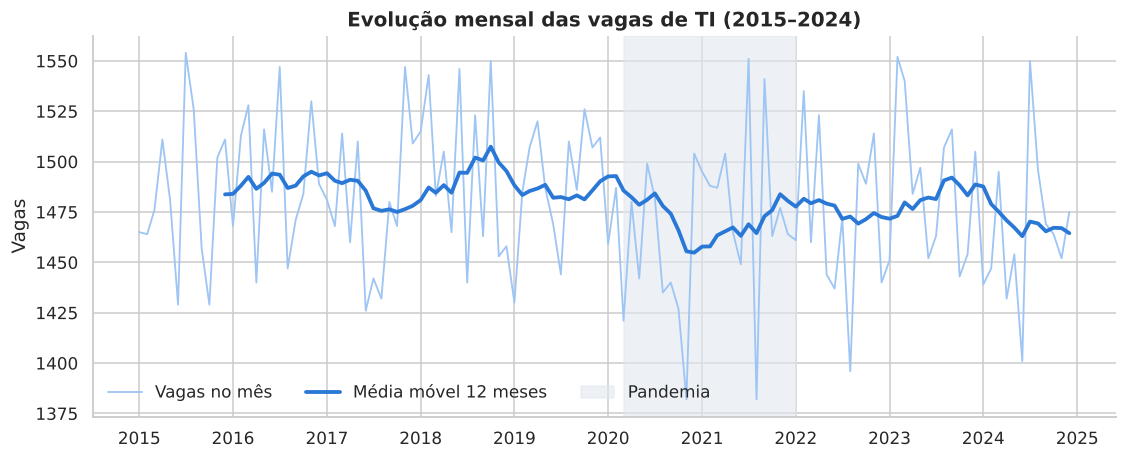

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
vagas,"17,805.00","17,918.00","17,737.00","17,944.00","17,883.00","17,458.00","17,766.00","17,670.00","17,864.00","17,574.00"
variacao_%,NaN,0.63,-1.01,1.17,-0.34,-2.38,1.76,-0.54,1.10,-1.62


In [9]:
mensal = df.groupby("data")["quantidade_vagas"].sum()
mm12 = mensal.rolling(12).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(mensal.index, mensal.values, color="#9ec5f4", lw=1.2, label="Vagas no mês")
ax.plot(mm12.index, mm12.values, color=PALETA[0], lw=2.5, label="Média móvel 12 meses")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31"), color="#e2e8f0", alpha=.6, label="Pandemia")
ax.set_title("Evolução mensal das vagas de TI (2015–2024)")
ax.set_ylabel("Vagas"); ax.legend(loc="lower left", frameon=False, ncol=3)
salvar(fig, "01_evolucao_vagas.png"); plt.show()

anual = df.groupby("ano")["quantidade_vagas"].sum().to_frame("vagas")
anual["variacao_%"] = anual["vagas"].pct_change() * 100
anual.T

**Interpretação:** o volume anual oscila entre ~17,4 mil e ~17,9 mil vagas (variações de no máximo ±2,4%). A média
móvel mostra um **mercado estável em volume**, com leve recuo em 2020 (início da pandemia) e recuperação em 2021.

### 8.2 Comparação entre cargos e crescimento por área

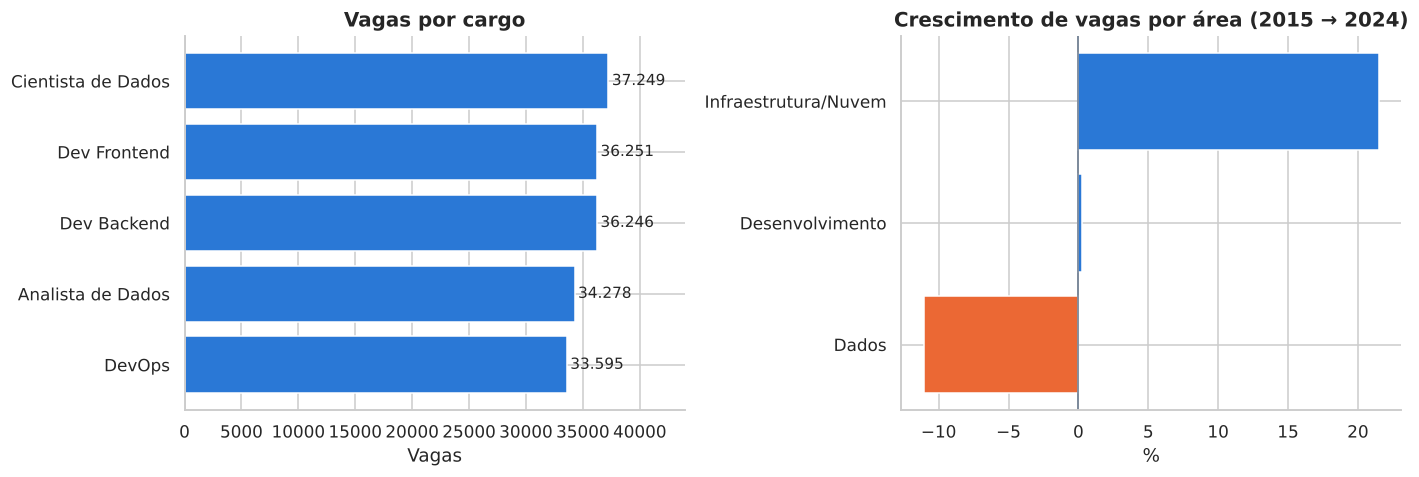

ano,2015,2024,crescimento_%
area,,,
Dados,8086,7192,-11.06
Desenvolvimento,6712,6729,0.25
Infraestrutura/Nuvem,3007,3653,21.48


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cargos = df.groupby("cargo")["quantidade_vagas"].sum().sort_values()
axes[0].barh(cargos.index, cargos.values, color=PALETA[0])
for i, v in enumerate(cargos.values):
    axes[0].text(v + 300, i, f"{v:,.0f}".replace(",", "."), va="center", fontsize=10)
axes[0].set_title("Vagas por cargo"); axes[0].set_xlim(0, cargos.max() * 1.18); axes[0].set_xlabel("Vagas")

area = df[df["ano"].isin([2015, 2024])].pivot_table(index="area", columns="ano", values="quantidade_vagas", aggfunc="sum")
area["crescimento_%"] = (area[2024] / area[2015] - 1) * 100
area = area.sort_values("crescimento_%")
cores = [PALETA[0] if v >= 0 else PALETA[1] for v in area["crescimento_%"]]
axes[1].barh(area.index, area["crescimento_%"], color=cores)
axes[1].axvline(0, color="#64748b", lw=1)
axes[1].set_title("Crescimento de vagas por área (2015 → 2024)"); axes[1].set_xlabel("%")
plt.tight_layout(); salvar(fig, "02_cargos_areas.png"); plt.show()
area

**Interpretação:** *Cientista de Dados* lidera (21,0% das vagas), mas a diferença para *DevOps*, o último colocado,
é de apenas ~11%: **a demanda é distribuída** entre os perfis. Na comparação 2015 × 2024, **Infraestrutura/Nuvem
(DevOps)** foi a área que mais cresceu (+21,5%), enquanto Dados recuou — coerente com o avanço da computação em nuvem.

### 8.3 Ranking e evolução das tecnologias

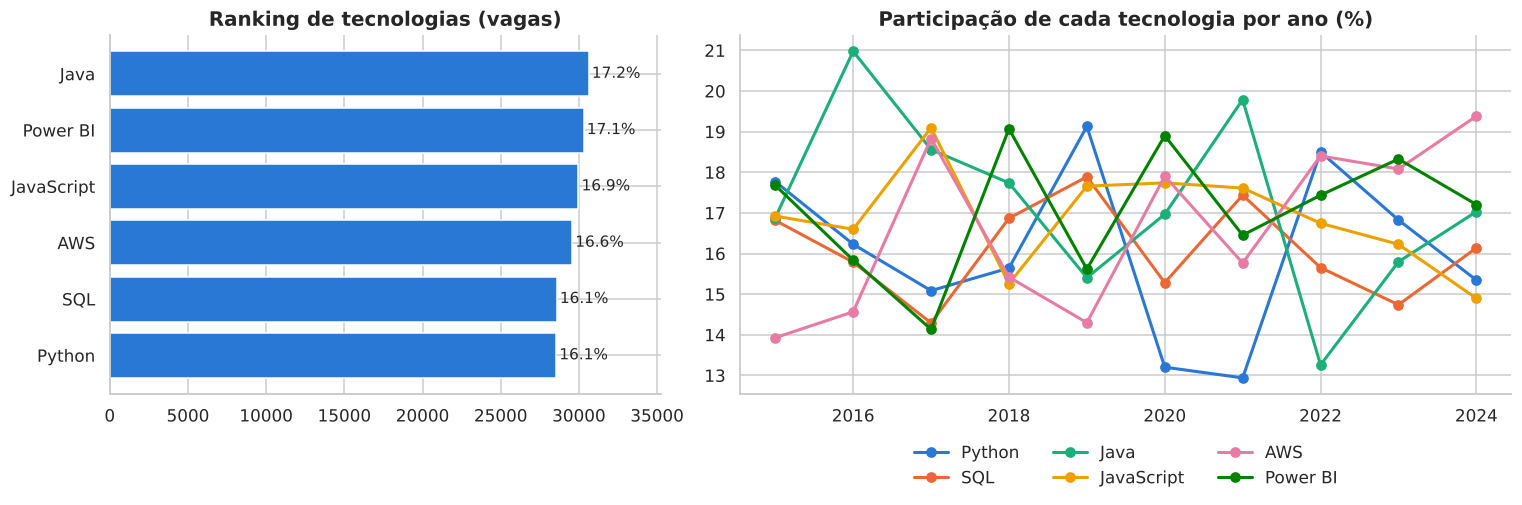

tecnologia,Python,JavaScript,SQL,Power BI,Java,AWS
variação 2015→2024 (p.p.),-2.42,-2.03,-0.68,-0.47,0.15,5.45


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.4]})
tec = df.groupby("tecnologia")["quantidade_vagas"].sum().sort_values()
axes[0].barh(tec.index, tec.values, color=PALETA[0])
for i, v in enumerate(tec.values):
    axes[0].text(v + 200, i, f"{v / tec.sum() * 100:.1f}%", va="center", fontsize=10)
axes[0].set_xlim(0, tec.max() * 1.15); axes[0].set_title("Ranking de tecnologias (vagas)")

part = df.pivot_table(index="ano", columns="tecnologia", values="quantidade_vagas", aggfunc="sum")
part = part.div(part.sum(axis=1), axis=0) * 100
for cor, t in zip(PALETA, ["Python", "SQL", "Java", "JavaScript", "AWS", "Power BI"]):
    axes[1].plot(part.index, part[t], marker="o", lw=2, color=cor, label=t)
axes[1].set_title("Participação de cada tecnologia por ano (%)")
axes[1].legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1))
plt.tight_layout(); salvar(fig, "03_tecnologias.png"); plt.show()
(part.loc[2024] - part.loc[2015]).sort_values().rename("variação 2015→2024 (p.p.)").to_frame().T

**Interpretação:** *Java* é a tecnologia mais frequente no acumulado (17,2%), mas as seis tecnologias ficam entre 16% e
17%. A liderança alterna ano a ano. Comparando 2015 e 2024, **AWS foi quem mais ganhou espaço** (≈ +5 p.p.), reforçando
o crescimento de DevOps/nuvem; *Python* e *JavaScript* perderam participação no recorte simulado.

### 8.4 Heatmap regional

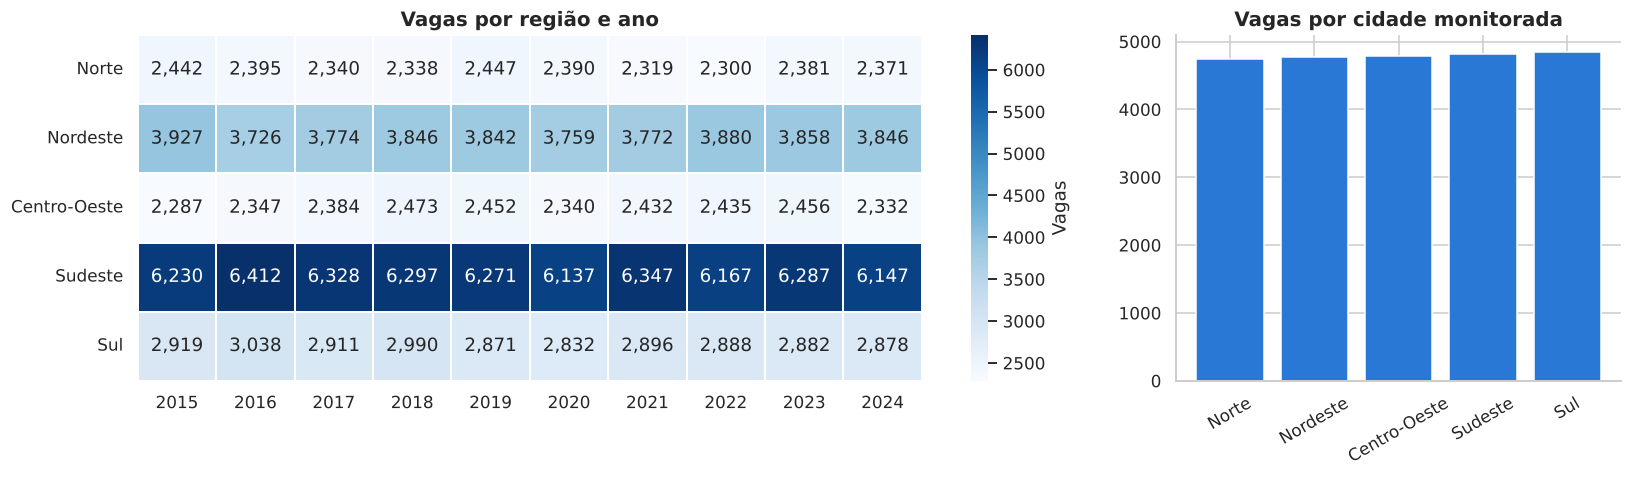

,vagas,cidades,vagas_por_cidade,participacao_pct
regiao,,,,
Norte,23723,5,"4,744.60",13.36
Nordeste,38230,8,"4,778.75",21.52
Centro-Oeste,23938,5,"4,787.60",13.48
Sudeste,62623,13,"4,817.15",35.26
Sul,29105,6,"4,850.83",16.39


In [12]:
ordem = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
heat = df.pivot_table(index="regiao", columns="ano", values="quantidade_vagas", aggfunc="sum").reindex(ordem)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(heat, annot=True, fmt=",.0f", cmap="Blues", linewidths=1, linecolor="white", ax=axes[0],
            cbar_kws={"label": "Vagas"})
axes[0].set_title("Vagas por região e ano"); axes[0].set_xlabel(""); axes[0].set_ylabel("")

reg = df.groupby("regiao").agg(vagas=("quantidade_vagas", "sum"), cidades=("cidade", "nunique")).reindex(ordem)
reg["vagas_por_cidade"] = reg["vagas"] / reg["cidades"]
axes[1].bar(reg.index, reg["vagas_por_cidade"], color=PALETA[0])
axes[1].set_title("Vagas por cidade monitorada"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); salvar(fig, "04_heatmap_regional.png"); plt.show()
reg.assign(participacao_pct=reg["vagas"] / reg["vagas"].sum() * 100)

**Interpretação:** o **Sudeste concentra 35,3%** das vagas, seguido do Nordeste (21,5%). Porém o Sudeste tem 13 cidades
monitoradas contra 5 no Norte e no Centro-Oeste. Normalizando por cidade, todas as regiões ficam entre ~4.750 e ~4.850
vagas/cidade (diferença de ~2%). A concentração absoluta é, portanto, efeito da **cobertura da amostra**, não de uma
demanda local maior.

### 8.5 Evolução salarial — nominal × real

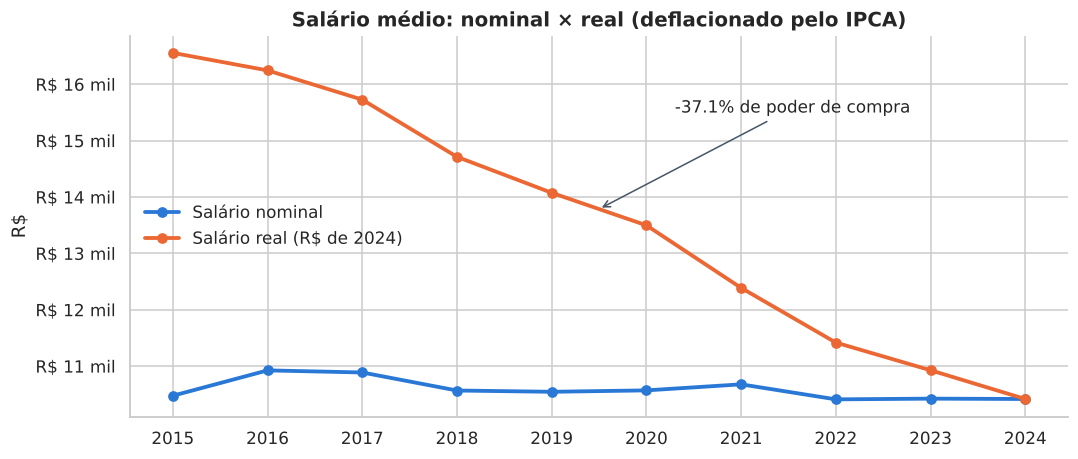

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
nominal,"10,476.19","10,925.99","10,888.98","10,568.82","10,546.36","10,571.21","10,678.32","10,412.06","10,424.68","10,418.36"
real,"16,558.09","16,247.07","15,728.05","14,713.85","14,075.91","13,498.92","12,389.33","11,419.24","10,928.20","10,418.36"


In [13]:
sal = df.groupby("ano").agg(nominal=("salario_medio", "mean"), real=("salario_real", "mean"))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sal.index, sal["nominal"], marker="o", lw=2.5, color=PALETA[0], label="Salário nominal")
ax.plot(sal.index, sal["real"], marker="o", lw=2.5, color=PALETA[1], label="Salário real (R$ de 2024)")
ax.annotate(f"-{(1 - sal['real'].iloc[-1] / sal['real'].iloc[0]) * 100:.1f}% de poder de compra",
            xy=(2019.5, sal["real"].loc[2019:2020].mean()), xytext=(2020.3, 15500), fontsize=11,
            arrowprops=dict(arrowstyle="->", color="#475569"))
ax.set_title("Salário médio: nominal × real (deflacionado pelo IPCA)")
ax.set_ylabel("R$"); ax.set_xticks(sal.index); ax.legend(frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v/1000:.0f} mil"))
salvar(fig, "05_salario_real.png"); plt.show()
sal.round(2).T

**Interpretação:** o salário **nominal** ficou praticamente parado (R$ 10.476 em 2015 → R$ 10.418 em 2024). Corrigido pelo
IPCA, o salário de 2015 equivale a R$ 16.558 em valores de 2024: houve **queda real de ~37%**. Logo, **não houve
crescimento salarial** — os profissionais perderam poder de compra, principalmente nos anos de inflação alta (2015 e 2021).

### 8.6 Senioridade e modalidade de trabalho

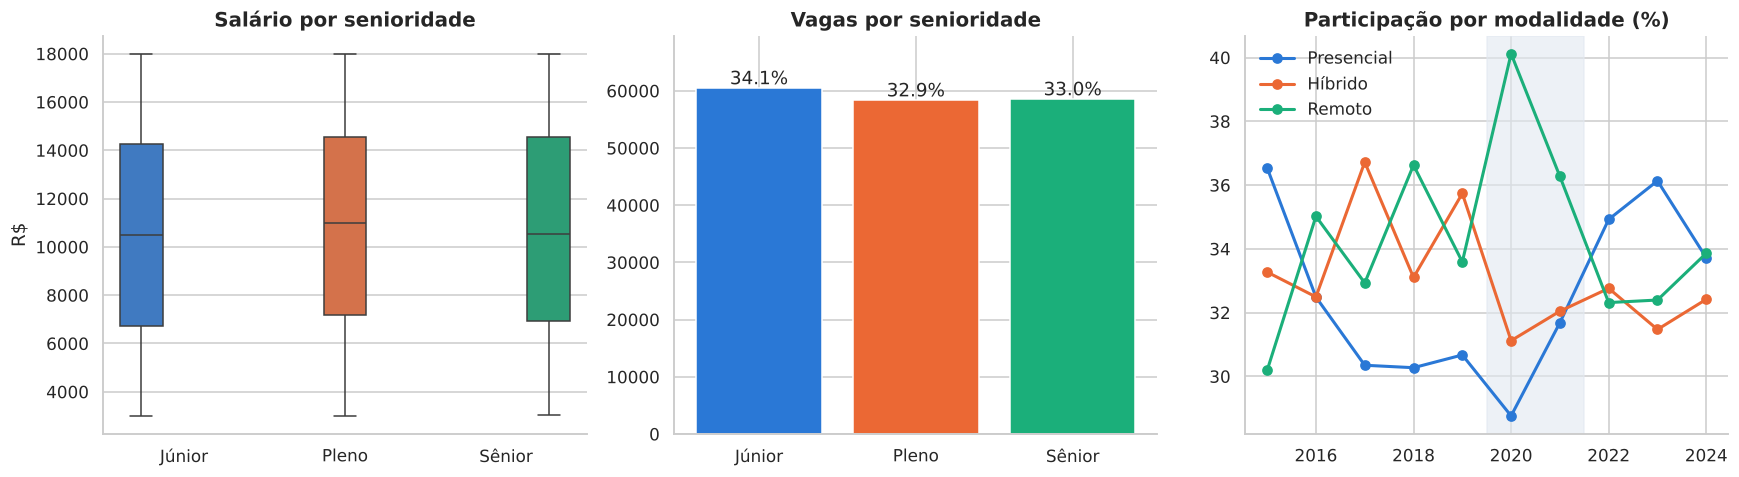

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
modalidade,,,,,,,,,,
Presencial,36.50,32.50,30.30,30.30,30.70,28.80,31.70,34.90,36.10,33.70
Híbrido,33.30,32.50,36.70,33.10,35.70,31.10,32.00,32.80,31.50,32.40
Remoto,30.20,35.00,32.90,36.60,33.60,40.10,36.30,32.30,32.40,33.90


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="senioridade", y="salario_medio", hue="senioridade", palette=PALETA[:3], legend=False, ax=axes[0])
axes[0].set_title("Salário por senioridade"); axes[0].set_xlabel(""); axes[0].set_ylabel("R$")

sen = df.groupby("senioridade", observed=True)["quantidade_vagas"].sum()
axes[1].bar(sen.index.astype(str), sen.values, color=PALETA[:3])
for i, v in enumerate(sen.values):
    axes[1].text(i, v + 600, f"{v / sen.sum() * 100:.1f}%", ha="center")
axes[1].set_title("Vagas por senioridade"); axes[1].set_ylim(0, sen.max() * 1.15)

mod = df.pivot_table(index="ano", columns="modalidade", values="quantidade_vagas", aggfunc="sum", observed=True)
mod = mod.div(mod.sum(axis=1), axis=0) * 100
for cor, m in zip(PALETA, mod.columns):
    axes[2].plot(mod.index, mod[m], marker="o", lw=2, color=cor, label=m)
axes[2].axvspan(2019.5, 2021.5, color="#e2e8f0", alpha=.6)
axes[2].set_title("Participação por modalidade (%)"); axes[2].legend(frameon=False)
plt.tight_layout(); salvar(fig, "06_senioridade_modalidade.png"); plt.show()
mod.round(1).T

**Interpretação:**
- **Senioridade:** *Júnior* é o nível com mais vagas (34,1%), mas a distribuição é quase igual entre os três níveis.
  As caixas salariais se sobrepõem: na base simulada a senioridade explica pouco do salário.
- **Modalidade:** o **remoto teve pico em 2020 (40,1%)**, no auge da pandemia, e depois voltou a dividir espaço com
  presencial e híbrido. No acumulado, o remoto é a modalidade predominante (34,3%).

### 8.7 Correlação estatística — dispersão salário × vagas

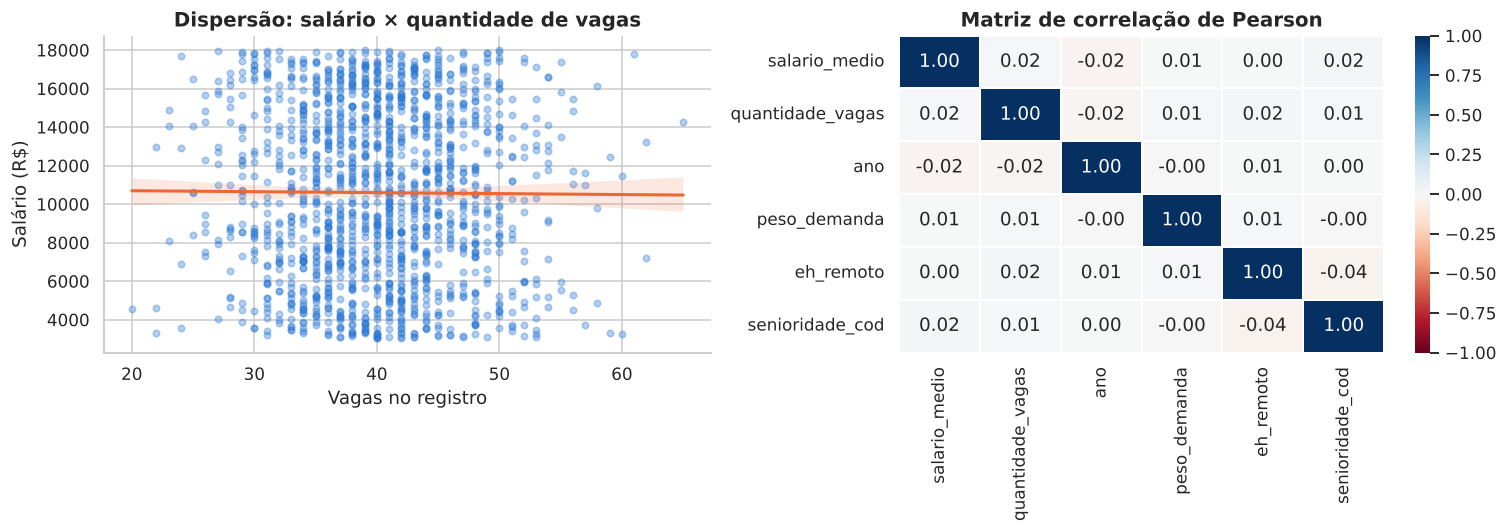

Pearson  salário × vagas: 0.0155
Spearman salário × vagas: 0.0154


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df.sample(1500, random_state=1), x="quantidade_vagas", y="salario_medio", ax=axes[0],
            scatter_kws=dict(alpha=.35, s=18, color=PALETA[0]), line_kws=dict(color=PALETA[1], lw=2))
axes[0].set_title("Dispersão: salário × quantidade de vagas")
axes[0].set_xlabel("Vagas no registro"); axes[0].set_ylabel("Salário (R$)")

num_cols = df.assign(senioridade_cod=df["senioridade"].cat.codes + 1)[
    ["salario_medio", "quantidade_vagas", "ano", "peso_demanda", "eh_remoto", "senioridade_cod"]]
corr = num_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu", vmin=-1, vmax=1, center=0, ax=axes[1], linewidths=1)
axes[1].set_title("Matriz de correlação de Pearson")
plt.tight_layout(); salvar(fig, "07_correlacao.png"); plt.show()

print(f"Pearson  salário × vagas: {df['salario_medio'].corr(df['quantidade_vagas']):.4f}")
print(f"Spearman salário × vagas: {df['salario_medio'].corr(df['quantidade_vagas'], method='spearman'):.4f}")

**Interpretação:** a correlação entre salário e quantidade de vagas é **desprezível** (r ≈ 0,02). Nenhum par de
variáveis numéricas apresenta correlação acima de |0,05|: oferecer mais vagas não está associado a salários maiores ou
menores. Isso é esperado em uma base simulada com sorteio independente das variáveis.

### 8.8 Tabela dinâmica — cargo × tecnologia

In [16]:
pd.pivot_table(df, index="cargo", columns="tecnologia", values="quantidade_vagas", aggfunc="sum",
               margins=True, margins_name="Total")

tecnologia,AWS,Java,JavaScript,Power BI,Python,SQL,Total
cargo,,,,,,,
Analista de Dados,6100,6223,5706,5089,5930,5230,34278
Cientista de Dados,5980,6456,6088,6396,6142,6187,37249
Dev Backend,5916,5997,6540,6229,5850,5714,36246
Dev Frontend,6038,6240,5901,6662,5273,6137,36251
DevOps,5535,5715,5737,5934,5357,5317,33595
Total,29569,30631,29972,30310,28552,28585,177619


## 9. Persistência em banco de dados (SQLAlchemy + SQLite)

A base tratada é gravada em `database/mercado_ti.db` com modelagem relacional (tabela fato + dimensões),
usando o módulo `utils/banco.py`, o mesmo usado pelo dashboard.

In [17]:
import sys
sys.path.append(str(RAIZ.resolve()))
from utils.banco import CONSULTAS, criar_banco, executar_sql
from utils.dados import preparar_base

base, _, ipca_db, _ = preparar_base(RAIZ / "dados" / "simulacao_mercado_ti_brasil.csv")
criar_banco(base, ipca_db)
executar_sql(CONSULTAS["Vagas e salário por região (JOIN fato × localidade)"])

,regiao,total_vagas,salario_ponderado,cidades
0,Sudeste,62623,"10,615.23",13
1,Nordeste,38230,"10,435.02",8
2,Sul,29105,"10,779.22",6
3,Centro-Oeste,23938,"10,908.85",5
4,Norte,23723,"10,307.46",5


## 10. Interpretação dos resultados

| Pergunta | Resposta |
|---|---|
| Cargos com maior demanda | Cientista de Dados (21,0%), seguido de Dev Frontend e Dev Backend (20,4% cada) |
| Tecnologias mais frequentes | Java (17,2%) e Power BI (17,1%); AWS é a que mais cresce |
| Crescimento salarial | Não: nominal estável e **queda real de ~37%** (IPCA) |
| Diferenças regionais | Sudeste lidera em volume (35,3%), mas por cidade as regiões se equivalem |
| Áreas que mais crescem | Infraestrutura/Nuvem (DevOps): +21,5% entre 2015 e 2024 |
| Nível mais exigido | Júnior (34,1%), com distribuição equilibrada |
| Regiões com mais oportunidades | Sudeste (absoluto) e Sul (vagas por cidade) |

## 11. Conclusão

O mercado de TI simulado é **estável em volume e diversificado**: nenhum cargo, tecnologia ou região domina de forma
isolada. As mudanças relevantes estão na **composição** — avanço de nuvem (AWS/DevOps), pico do trabalho remoto
durante a pandemia — e, principalmente, na **remuneração real**, que perdeu cerca de um terço do poder de compra
por não acompanhar a inflação.

**Recomendações:** profissionais devem combinar uma linguagem de programação com dados e nuvem; empresas que
corrigirem salários pela inflação terão vantagem na retenção; a contratação remota permite acessar talentos de todas
as regiões.

**Limitação:** os dados são simulados e quase uniformes; as conclusões demonstram o método analítico e não
representam fielmente o mercado brasileiro.